In [1]:
import tarfile
import numpy as np
import pickle
import matplotlib.pyplot as plt
import time
import os

from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")


TensorFlow Version: 2.19.0
Keras Version: 3.10.0


### 1. Data Loading and Preprocessing

In [ ]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

def load_cifar10_batch(file_path):
    data_batch = unpickle(file_path)
    X = data_batch[b'data']
    y = data_batch[b'labels']
    X = X.reshape(len(X), 3, 32, 32).transpose(0, 2, 3, 1)
    return X, y

def load_cifar10_dataset(dataset_path):
    X_train_list = []
    y_train_list = []
    for i in range(1, 6):
        X, y = load_cifar10_batch(os.path.join(dataset_path, f'data_batch_{i}'))
        X_train_list.append(X)
        y_train_list.append(y)
    X_train = np.concatenate(X_train_list)
    y_train = np.concatenate(y_train_list)

    X_test, y_test = load_cifar10_batch(os.path.join(dataset_path, 'test_batch'))

    # Convert y_test to numpy array
    y_test = np.array(y_test)

    # Normalize pixel values to [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Convert labels to one-hot encoding for CNN
    y_train_one_hot = to_categorical(y_train, num_classes=10)
    y_test_one_hot = to_categorical(y_test, num_classes=10)

    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")

    return (X_train, y_train, y_train_one_hot), (X_test, y_test, y_test_one_hot)

# Extract the dataset
cifar10_tgz_path = '/content/cifar-10-python.tar.gz'
extraction_path = '/content/cifar-10-batches-py'

if not os.path.exists(extraction_path):
    print(f"Extracting {cifar10_tgz_path} to {extraction_path}...")
    with tarfile.open(cifar10_tgz_path, 'r:gz') as tar:
        tar.extractall(path='/content/', filter='data') # Added filter='data'
    print("Extraction complete.")
else:
    print(f"Dataset already extracted to {extraction_path}.")

(X_train_raw, y_train_labels, y_train_one_hot), (X_test_raw, y_test_labels, y_test_one_hot) = load_cifar10_dataset(extraction_path)


### 2. Autoencoder for Feature Compression

In [12]:
# Define the Autoencoder architecture
latent_dim = 64 # Dimension of the compressed representation

# Encoder
encoder_inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_inputs)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # Output shape (4, 4, 128)

# Flatten and project to latent_dim
x = layers.Flatten()(x)
encoder_outputs = layers.Dense(latent_dim, activation='relu')(x)

encoder = Model(encoder_inputs, encoder_outputs, name='encoder')

# Decoder
decoder_inputs = keras.Input(shape=(latent_dim,))
# Reshape back to the shape before flattening, (4, 4, 128)
x = layers.Dense(4 * 4 * 128, activation='relu')(decoder_inputs)
x = layers.Reshape((4, 4, 128))(x)

x = layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x) # Output shape (32, 32, 32)
decoder_outputs = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x) # Output shape (32, 32, 3)

decoder = Model(decoder_inputs, decoder_outputs, name='decoder')

# Autoencoder
autoencoder_inputs = keras.Input(shape=(32, 32, 3))
encoded_output = encoder(autoencoder_inputs)
decoded_output = decoder(encoded_output)
autoencoder = Model(autoencoder_inputs, decoded_output, name='autoencoder')

autoencoder.compile(optimizer='adam', loss='mse')

print("Autoencoder Summary:")
autoencoder.summary()
print("\nEncoder Summary:")
encoder.summary()

# Train the Autoencoder
print("\nTraining Autoencoder...")
autoencoder_train_start_time = time.time()
history_autoencoder = autoencoder.fit(X_train_raw, X_train_raw,
                                      epochs=10, # Reduced epochs for faster execution
                                      batch_size=128,
                                      shuffle=True,
                                      validation_data=(X_test_raw, X_test_raw))
autoencoder_train_end_time = time.time()
autoencoder_train_time = autoencoder_train_end_time - autoencoder_train_start_time
print(f"Autoencoder training time: {autoencoder_train_time:.2f} seconds")

# Extract compressed features
print("\nExtracting compressed features...")
features_train_compressed_ae = encoder.predict(X_train_raw)
features_test_compressed_ae = encoder.predict(X_test_raw)

print(f"Compressed training features shape: {features_train_compressed_ae.shape}")
print(f"Compressed test features shape: {features_test_compressed_ae.shape}")


Autoencoder Summary:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 64)             │       224,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 32, 32, 3)      │       373,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 598,211 (2.28 MB)

 Trainable params: 598,211 (2.28 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       131,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,384 (876.50 KB)

 Trainable params: 224,384 (876.50 KB)

 Non-trainable params: 0 (0.00 B)


Training Autoencoder...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 0.0360 - val_loss: 0.0168
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0162 - val_loss: 0.0141
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0137 - val_loss: 0.0145
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0128 - val_loss: 0.0119
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0119 - val_loss: 0.0120
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0113 - val_loss: 0.0112
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0110 - val_loss: 0.0108
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0109 - val_loss: 0.0106
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0106 - val_loss: 0.0105
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0105 - val_loss: 0.0106
Autoencoder training time: 62.21 seconds

Extracting compressed features...
1563/1563 ━━━━━━━━━━━━━━━━━

### 3. Visualize Reconstructed Images from Autoencoder

Generating reconstructed images...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


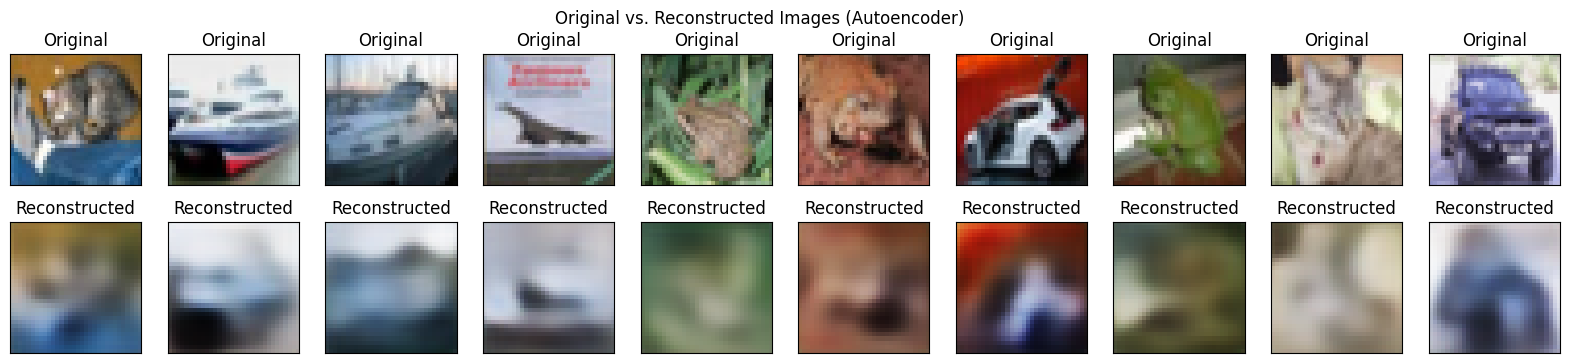

In [13]:
def plot_reconstructions(images, reconstructed_images, n=10):
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Original Image
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images[i])
        plt.title("Original")
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Reconstructed Image
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed_images[i])
        plt.title("Reconstructed")
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.suptitle("Original vs. Reconstructed Images (Autoencoder)")
    plt.show()

print("Generating reconstructed images...")
reconstructed_images = autoencoder.predict(X_test_raw[:10])
plot_reconstructions(X_test_raw[:10], reconstructed_images)


### 4. Convolutional Neural Network (CNN) Training

In [14]:
# Define the CNN architecture
cnn_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("CNN Model Summary:")
cnn_model.summary()

# Train the CNN
print("\nTraining CNN...")
cnn_train_start_time = time.time()
history_cnn = cnn_model.fit(X_train_raw, y_train_one_hot,
                          epochs=10, # Reduced epochs for faster execution
                          batch_size=64,
                          validation_data=(X_test_raw, y_test_one_hot))
cnn_train_end_time = time.time()
cnn_train_time = cnn_train_end_time - cnn_train_start_time
print(f"CNN training time: {cnn_train_time:.2f} seconds")

# Evaluate CNN performance
print("\nEvaluating CNN on raw images...")
cnn_inference_start_time = time.time()
loss_cnn, accuracy_cnn = cnn_model.evaluate(X_test_raw, y_test_one_hot, verbose=0)
cnn_inference_end_time = time.time()
cnn_inference_time = cnn_inference_end_time - cnn_inference_start_time

print(f"CNN Test Accuracy (raw images): {accuracy_cnn:.4f}")
print(f"CNN Inference time: {cnn_inference_time:.4f} seconds")

y_pred_cnn = np.argmax(cnn_model.predict(X_test_raw), axis=1)
print("\nCNN Classification Report:")
print(classification_report(y_test_labels, y_pred_cnn, target_names=[str(i) for i in range(10)]))


CNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.3405 - loss: 1.7802 - val_accuracy: 0.5424 - val_loss: 1.2698
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5692 - loss: 1.2073 - val_accuracy: 0.5781 - val_loss: 1.1640
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6284 - loss: 1.0528 - val_accuracy: 0.6466 - val_loss: 0.9965
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6709 - loss: 0.9397 - val_accuracy: 0.6667 - val_loss: 0.9538
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6981 - loss: 0.8630 - val_accuracy: 0.6942 - val_loss: 0.8877
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7215 - loss: 0.7926 - val_accuracy: 0.7047 - val_loss: 0.8508
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7471 - loss: 0.7276 - val_accuracy: 0.7050 - val_loss: 0.8706
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7624 - loss: 0.6901 -

### 5. Support Vector Machine (SVM) Training on Compressed Features

In [15]:
# Scale the compressed features for SVM
scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train_compressed_ae)
features_test_scaled = scaler.transform(features_test_compressed_ae)

# Train SVM
print("\nTraining SVM on Autoencoder-extracted features...")
svm_model = SVC(kernel='rbf', C=1.0, random_state=42) # Using RBF kernel
svm_train_start_time = time.time()
svm_model.fit(features_train_scaled, y_train_labels)
svm_train_end_time = time.time()
svm_train_time = svm_train_end_time - svm_train_start_time
print(f"SVM training time: {svm_train_time:.2f} seconds")

# Evaluate SVM performance
print("\nEvaluating SVM on compressed features...")
svm_inference_start_time = time.time()
y_pred_svm = svm_model.predict(features_test_scaled)
svm_inference_end_time = time.time()
svm_inference_time = svm_inference_end_time - svm_inference_start_time

accuracy_svm = accuracy_score(y_test_labels, y_pred_svm)
print(f"SVM Test Accuracy (compressed features): {accuracy_svm:.4f}")
print(f"SVM Inference time: {svm_inference_time:.4f} seconds")

print("\nSVM Classification Report:")
print(classification_report(y_test_labels, y_pred_svm, target_names=[str(i) for i in range(10)]))



Training SVM on Autoencoder-extracted features...
SVM training time: 173.93 seconds

Evaluating SVM on compressed features...
SVM Test Accuracy (compressed features): 0.5346
SVM Inference time: 39.1860 seconds

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.61      0.61      1000
           1       0.63      0.67      0.65      1000
           2       0.41      0.38      0.40      1000
           3       0.38      0.39      0.39      1000
           4       0.46      0.43      0.45      1000
           5       0.49      0.42      0.45      1000
           6       0.51      0.62      0.56      1000
           7       0.61      0.55      0.58      1000
           8       0.64      0.66      0.65      1000
           9       0.60      0.61      0.60      1000

    accuracy                           0.53     10000
   macro avg       0.53      0.53      0.53     10000
weighted avg       0.53      0.53      0.53     10000



### 6. Detailed Analysis and Comparison

In [16]:
# Summary of Results
print("\n--- Model Performance Summary ---")
print(f"CNN Test Accuracy (raw images): {accuracy_cnn:.4f}")
print(f"SVM Test Accuracy (compressed features): {accuracy_svm:.4f}")

print("\n--- Training and Inference Times ---")
print(f"Autoencoder Training Time: {autoencoder_train_time:.2f} seconds")
print(f"CNN Training Time: {cnn_train_time:.2f} seconds")
print(f"CNN Inference Time: {cnn_inference_time:.4f} seconds")
print(f"SVM Training Time (on compressed features): {svm_train_time:.2f} seconds")
print(f"SVM Inference Time (on compressed features): {svm_inference_time:.4f} seconds")



--- Model Performance Summary ---
CNN Test Accuracy (raw images): 0.7079
SVM Test Accuracy (compressed features): 0.5346

--- Training and Inference Times ---
Autoencoder Training Time: 62.21 seconds
CNN Training Time: 41.43 seconds
CNN Inference Time: 1.5225 seconds
SVM Training Time (on compressed features): 173.93 seconds
SVM Inference Time (on compressed features): 39.1860 seconds


### 7. Detailed Combined Prediction Analysis and Ensemble Insights

In [18]:
print("\n--- Detailed Combined Prediction Analysis ---")

# Determine correctness for each model
cnn_correct = (y_pred_cnn == y_test_labels)
svm_correct = (y_pred_svm == y_test_labels)

# Categorize predictions
both_correct = np.sum(cnn_correct & svm_correct)
cnn_only_correct = np.sum(cnn_correct & ~svm_correct)
svm_only_correct = np.sum(~cnn_correct & svm_correct)
both_incorrect = np.sum(~cnn_correct & ~svm_correct)

total_samples = len(y_test_labels)

print(f"Total Test Samples: {total_samples}")
print(f"CNN Accuracy: {accuracy_cnn:.4f}")
print(f"SVM Accuracy: {accuracy_svm:.4f}")

print("\n--- Prediction Overlap Analysis ---")
print(f"- Samples where both CNN and SVM were CORRECT: {both_correct} ({both_correct/total_samples:.2%})")
print(f"- Samples where only CNN was CORRECT: {cnn_only_correct} ({cnn_only_correct/total_samples:.2%})")
print(f"- Samples where only SVM was CORRECT: {svm_only_correct} ({svm_only_correct/total_samples:.2%})")
print(f"- Samples where both CNN and SVM were INCORRECT: {both_incorrect} ({both_incorrect/total_samples:.2%})")

print("\n--- Ensemble Strategy Exploration ---")
print("The overlap analysis indicates that while CNN is generally superior, SVM still correctly identifies some samples that CNN misses. This suggests potential benefits from an ensemble strategy.")

# Simple Ensemble Strategy: Majority Vote (with tie-breaking for 2 models)
# If CNN and SVM agree, use their common prediction.
# If they disagree, a common strategy is to defer to the stronger model (CNN).

y_pred_combined_simple = np.array([y_pred_cnn[i] if y_pred_cnn[i] == y_pred_svm[i] else y_pred_cnn[i] for i in range(total_samples)])
accuracy_combined_simple = accuracy_score(y_test_labels, y_pred_combined_simple)

print(f"\n- Accuracy of a simple ensemble (deferring to CNN on disagreement): {accuracy_combined_simple:.4f}")
print("  *Note: This specific ensemble defaults to CNN's prediction when models disagree. As CNN already has higher individual accuracy, this simple method will likely yield an accuracy similar to (or exactly the same as) CNN's standalone accuracy, as seen here.*")

print("\nMore sophisticated ensemble methods could involve:")
print("1.  **Weighted Averaging/Voting:** If models output probabilities, assign higher weights to the stronger model.")
print("2.  **Stacking (Meta-Learner):** Train a separate classifier (e.g., Logistic Regression) on the predictions (or even class probabilities) of the base models (CNN and SVM) to make the final decision. This can learn how to best combine their insights.")
print("3.  **Confidence-based Fusion:** Use model confidence scores; if one model is highly confident, trust its prediction. If both are uncertain, rely on the stronger model or a meta-learner.")



--- Detailed Combined Prediction Analysis ---
Total Test Samples: 10000
CNN Accuracy: 0.7079
SVM Accuracy: 0.5346

--- Prediction Overlap Analysis ---
- Samples where both CNN and SVM were CORRECT: 4509 (45.09%)
- Samples where only CNN was CORRECT: 2570 (25.70%)
- Samples where only SVM was CORRECT: 837 (8.37%)
- Samples where both CNN and SVM were INCORRECT: 2084 (20.84%)

--- Ensemble Strategy Exploration ---
The overlap analysis indicates that while CNN is generally superior, SVM still correctly identifies some samples that CNN misses. This suggests potential benefits from an ensemble strategy.

- Accuracy of a simple ensemble (deferring to CNN on disagreement): 0.7079
  *Note: This specific ensemble defaults to CNN's prediction when models disagree. As CNN already has higher individual accuracy, this simple method will likely yield an accuracy similar to (or exactly the same as) CNN's standalone accuracy, as seen here.*

More sophisticated ensemble methods could involve:
1.  **We

### 9. Visualize Prediction Differences between CNN and SVM

Visualizing samples where CNN and SVM predictions differ...


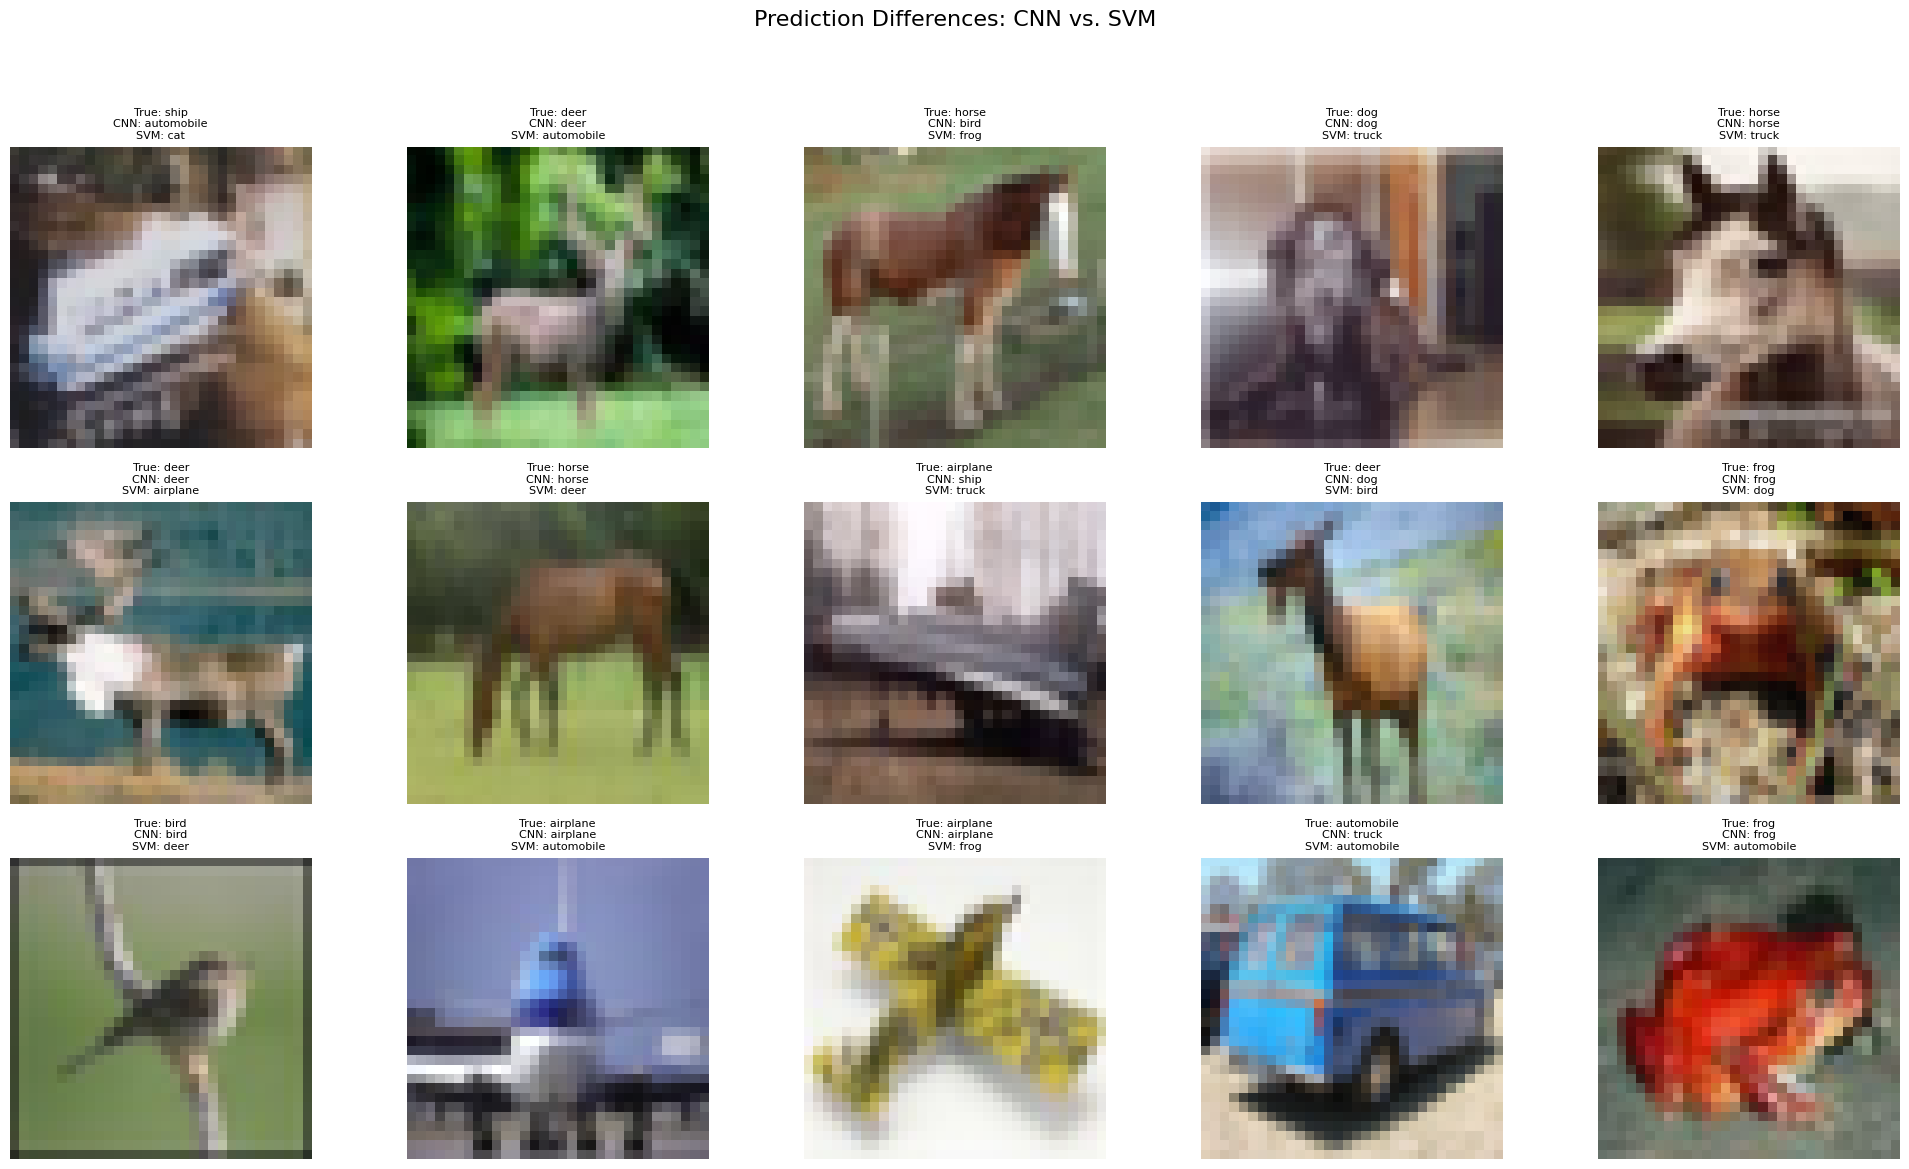

In [20]:
def visualize_prediction_differences(images, true_labels, cnn_preds, svm_preds, n=10):
    diff_indices = np.where(cnn_preds != svm_preds)[0]

    if len(diff_indices) == 0:
        print("CNN and SVM predictions are identical on the test set. No differences to visualize.")
        return

    # Select a random subset of differing predictions
    num_to_display = min(n, len(diff_indices))
    selected_indices = np.random.choice(diff_indices, num_to_display, replace=False)

    plt.figure(figsize=(20, 4 * num_to_display // 5 + 4)) # Adjust figure size dynamically
    plt.suptitle("Prediction Differences: CNN vs. SVM", fontsize=16)

    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    for i, idx in enumerate(selected_indices):
        ax = plt.subplot(num_to_display // 5 + 1, 5, i + 1) # Arrange in rows of 5
        plt.imshow(images[idx])
        plt.title(f"True: {class_names[true_labels[idx]]}\nCNN: {class_names[cnn_preds[idx]]}\nSVM: {class_names[svm_preds[idx]]}", fontsize=8)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

print("Visualizing samples where CNN and SVM predictions differ...")
visualize_prediction_differences(X_test_raw, y_test_labels, y_pred_cnn, y_pred_svm, n=15) # Visualize 15 samples